https://github.com/krlawrence/graph/blob/master/sample-data/air-routes-latest-nodes.csv

#Import Libraries

In [ ]:
from google.colab import drive
#drive.mount('/content/drive')
!pip install dgl
!pip install node2vec

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 18.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 10.9 MB/s eta 0:00:00
  Attempting uninstall: networkx
    Found existing installation: networkx 3.2.1
    Uninstalling networkx-3.2.1:
      Successfully uninstalled networkx-3.2.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
lida 0.0.10 requires fastapi, which is not installed.
lida 0.0.10 requires kaleido, which is not installed.
lida 0.0.10 requires python-multipart, which is not installed.
lida 0.0.10 requires uvicorn, which is not installed.


In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import os

from gensim.models import Word2Vec
from node2vec import Node2Vec

import torch
from torch import tensor
import torch.nn as nn
import torch.nn.functional as F

import dgl
import dgl.nn as dglnn
from dgl.nn import SAGEConv
import dgl.function as fn
from sklearn.feature_extraction.text import CountVectorizer

import scipy.sparse as sp

import itertools

%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

from sklearn.metrics import ConfusionMatrixDisplay, precision_recall_fscore_support, accuracy_score

# Create Graph from DataFrames

In [ ]:
# Define the paths to your CSV files
edges_path = "/content/drive/MyDrive/[3] Colab Notebooks/Airline Link Prediction GNN/air-routes-latest-edges.csv"
nodes_path = "/content/drive/MyDrive/[3] Colab Notebooks/Airline Link Prediction GNN/air-routes-latest-nodes.csv"
#three_letter_code_path = "/content/drive/MyDrive/[3] Colab Notebooks/Airline Problem/wikipedia-iso-country-codes.csv"

# Load the data from CSV files into Pandas DataFrames
edges_df = pd.read_csv(edges_path)
nodes_df = pd.read_csv(nodes_path)
#three_letter_df = pd.read_csv(three_letter_code_path)
#nodes_df = pd.merge(nodes_df, three_letter_df, how='left', left_on='country:string', right_on='Alpha-2 code')


# Remove the first row (index 0) from both DataFrames
edges_df = edges_df.iloc[1:]
nodes_df = nodes_df.iloc[1:]
nodes_df["location"] = nodes_df.apply(lambda row: (row["lon:double"],row["lat:double"]), axis=1)


# Filter the nodes_df to include only nodes with "type:string" label of "airport"
nodes_df = nodes_df[nodes_df['type:string'] == 'airport']
# Filter the edges_df to exclude rows where "~from" or "~to" fields are >= 3505
edges_df = edges_df[(edges_df['~from'] < 3505) & (edges_df['~to'] < 3505)]


#filter data for more efficient iteration
nodes_df = nodes_df[['~id','country:string', 'desc:string', 'city:string','location']]
edges_df = edges_df[['~from', '~to','dist:int']]
nodes_df.columns = ['id', 'area_code', 'airport', 'city','location']
nodes_df.set_index('id', inplace=True)
edges_df.columns = ['from', 'to', 'distance']



#print(nodes_df.head())
# Create an empty NetworkX graph
G = nx.Graph()  # You can use DiGraph or MultiGraph if your data represents directed or multi-edges.

# Add nodes to the graph with labels and attributes
for index, row in nodes_df.iterrows():
    node_id = index
    country_key = row['area_code']
    airport = row['airport']
    city = row['city']
    locat = row['location']
    G.add_node(node_id, country=country_key, airport=airport, city=city, location=locat)


# Add edges to the graph with the "dist:int" attribute
for _, row in edges_df.iterrows():
    source_node = row['from'].astype(int)
    target_node = row['to'].astype(int)
    edge_distance = row['distance']
    G.add_edge(source_node, target_node, distance=edge_distance)


#Plot Graph with Nodes in Geographical Locations
(Latitude and Longitude)

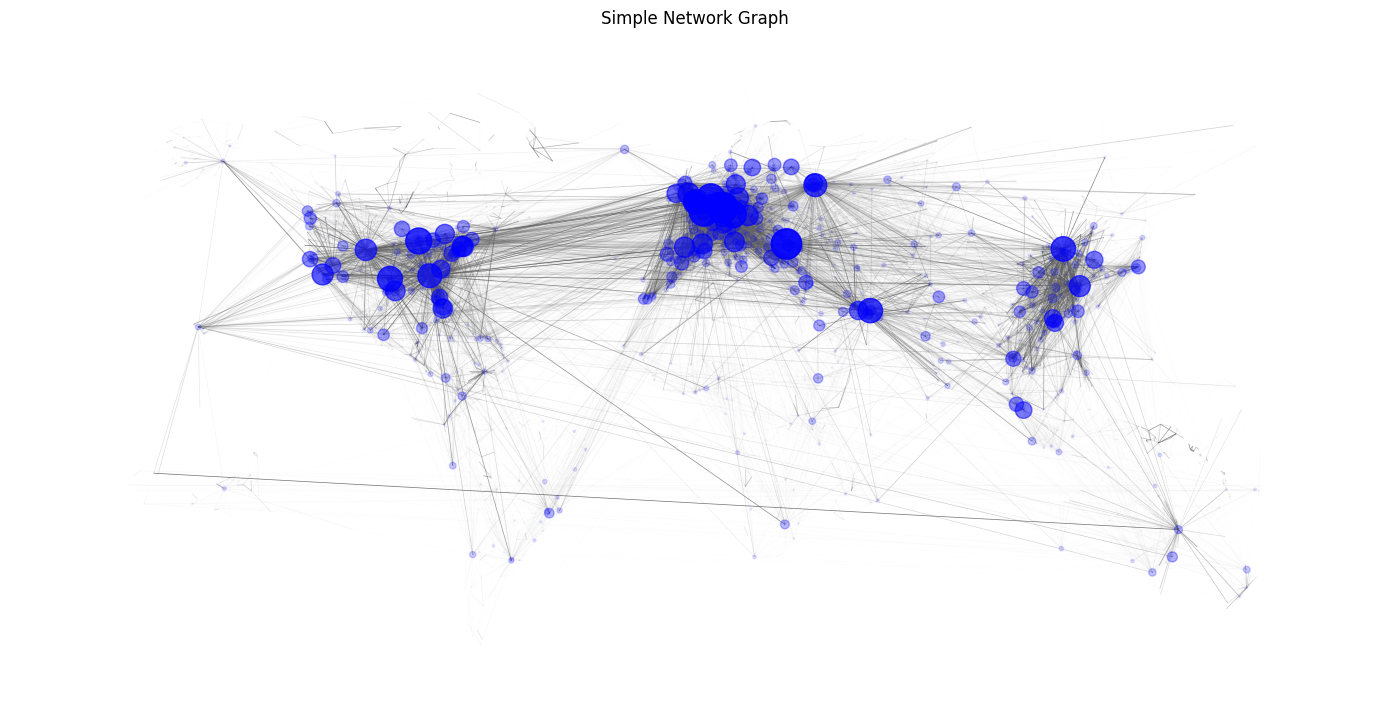

In [ ]:
# Draw the graph
# Draw the graph using custom node positions
plt.figure(figsize=(14,7))

pos = nx.get_node_attributes(G,"location")

#labels = nx.get_node_attributes(G, 'country')
node_size = [0.005*G.degree[v]**2 for v in G]
#node_size=50
alpha = [0.003*G.degree[v] for v in G]
edge_width = [0.0015*G[u][v]['distance'] for u,v in G.edges()]


nx.draw_networkx(G, pos, alpha=alpha, with_labels=False, edge_color='0.4', node_color='blue', node_size = node_size, width=0.5)

plt.axis('off')
plt.tight_layout();
plt.title("Simple Network Graph")
plt.show()

In [ ]:
def plot_detailed_graph(G, country_labels, emphasize_greater=True, degree_threshold=10, edge_highlight=None, labeled_nodes=True):
  # Draw the graph
  plt.figure(figsize=(14,7))
  pos = nx.get_node_attributes(G, "location")

  #degree_threshold = 10
  if emphasize_greater:
    filtered_nodes = [node for node in G.nodes() if G.degree[node] > degree_threshold]
  else:
    filtered_nodes = [node for node in G.nodes() if G.degree[node] < degree_threshold]
  filtered_edges = [(u, v) for u, v in G.edges() if u in filtered_nodes and v in filtered_nodes]

  filtered_node_degrees = {node: G.degree[node] for node in filtered_nodes}


  #node_size = 150
  node_size = [0.00005 * degree**3 for degree in filtered_node_degrees.values()]
  alpha = 1
  #alpha = [0.003 * G.degree[v] for v in G]
  edge_width = [0.00005 * G[u][v]['distance'] for u, v in G.edges()]

  # Draw only the filtered nodes and edges
  nx.draw_networkx_nodes(G, pos, nodelist=filtered_nodes, node_size=node_size, alpha=alpha, node_color='blue')
  nx.draw_networkx_edges(G, pos, edgelist=filtered_edges, width=edge_width, edge_color='0.5')

  if labeled_nodes:
    if emphasize_greater:
      nx.draw_networkx_labels(G, pos, labels=country_labels, font_size=10, font_color='yellow')
    else:
      nx.draw_networkx_labels(G, pos, labels=country_labels, font_size=10, font_color='black')

  if edge_highlight:
    if emphasize_greater:
      highlight_edges = [(u, v) for u, v in filtered_edges if G[u][v]['distance']>edge_highlight]
    else:
      highlight_edges = [(u, v) for u, v in filtered_edges if G[u][v]['distance']<edge_highlight]
    nx.draw_networkx_edges(G, pos, edgelist=highlight_edges, edge_color='r', alpha=1)

  #plt.axis('off')
  plt.tight_layout();
  plt.title("Airport Network Graph")
  plt.show()


degrees = dict(G.degree())



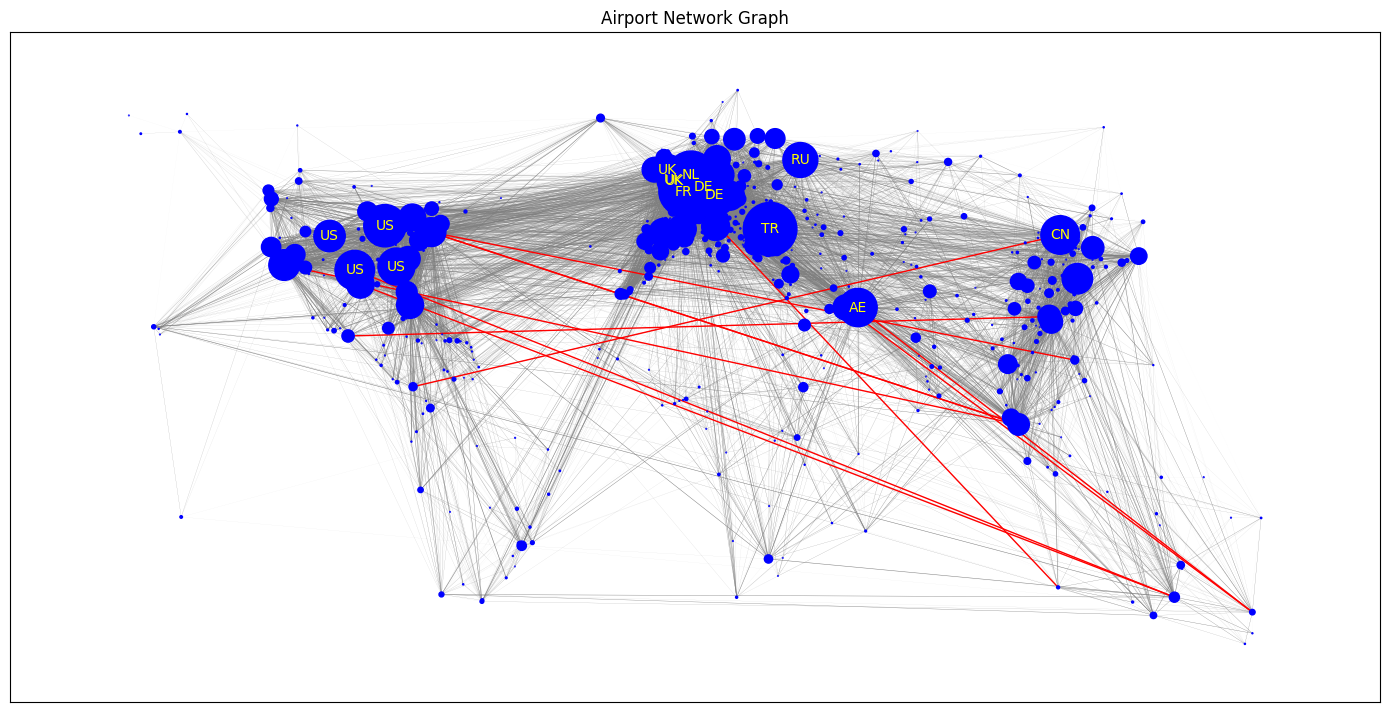

In [ ]:
# @title Click Choose Params for Graph Display {run: "auto"}
emphasize_greater = True # @param {type:"boolean"}

# Sort nodes by degree in descending order and take the top 20
labeled_nodes = 15 #@param {type:"slider", min:0, max:100, step:5}
degree_threshold=15 #@param {type:"slider", min:0, max:200, step:5}
edge_highlight_threshold=8500 #@param {type:"slider", min:0, max:9000, step:50}

if labeled_nodes:
  if emphasize_greater :
    sorted_degrees = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:labeled_nodes]
  else:
    sorted_degrees = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[-labeled_nodes:]
# Create a dictionary with node number and "Country" attribute for the top 20 nodes
node_to_country = {node:G.nodes[node]["country"] for node, _ in sorted_degrees}

plot_detailed_graph(G, node_to_country, emphasize_greater=emphasize_greater, degree_threshold=degree_threshold,  edge_highlight=edge_highlight_threshold, labeled_nodes=labeled_nodes)

In [ ]:
# Calculate and print node centralities, betweenness centralities, and closeness centralities
node_centralities = nx.degree_centrality(G)
betweenness_centralities = nx.betweenness_centrality(G)
closeness_centralities = nx.closeness_centrality(G)
def diameter_path():
  connected_components = list(nx.connected_components(G))
  for component_nodes in connected_components:
      subgraph = G.subgraph(component_nodes)
      #diameter = nx.diameter(subgraph)
      diameter_nodes = nx.center(subgraph)
      diameter = len(diameter_nodes)
      print(f"Diameter: {diameter} for this subgraph path: {diameter_nodes}")
#diameter_path()
##################print_highlight_edges

In [ ]:
def print_metrics(reverse, count=15, node=False, betweenness=False, closeness=False, distances=False, total_airport_distances=False, distances_per_route=False):

  if node:
    sorted_node_centralities = sorted(node_centralities.items(), key=lambda x: x[1], reverse=reverse)
    print("Node Centralities (Normalized Number of Connections, for Dave: 5 Connections/8 Possible Connections):")
    for node, centrality in sorted_node_centralities[:count]:
        print(f"{node}: {G.nodes[node]['airport']} ({G.nodes[node]['city']},{G.nodes[node]['country']}): {centrality}")

  if betweenness:
    sorted_betweenness_centralities = sorted(betweenness_centralities.items(), key=lambda x: x[1], reverse=reverse)
    print("\nBetweenness Centralities (How often a node occurs on a path between two other node, Ex: How many people kind of know each other through Jim):")
    for node, centrality in sorted_betweenness_centralities[:count]:
        print(f"{node}: {G.nodes[node]['airport']} ({G.nodes[node]['city']},{G.nodes[node]['country']}): {centrality}")

  if closeness:
    sorted_closeness_centralities = sorted(closeness_centralities.items(), key=lambda x: x[1], reverse=reverse)
    print("""\nCloseness Centralities (How close a node is to all other nodes.
    Even if someone is not directly friends with everyone,is there a low number of
    edges required to connect them to others):""")
    for node, centrality in sorted_closeness_centralities[:count]:
        print(f"{node}: {G.nodes[node]['airport']} ({G.nodes[node]['city']},{G.nodes[node]['country']}): {centrality}")

  if distances:
    sorted_edges = sorted(G.edges(data=True), key=lambda x: x[2]['distance'], reverse=reverse)
    longest_flights = [(u, v)for u, v, _ in sorted_edges[:count]]
    print("\nLongest/Shortest Flights in the World")
    for u,v in longest_flights:
      print(f"{G.nodes[u]['airport']}({G.nodes[u]['city']},{G.nodes[u]['country']}) to {G.nodes[v]['airport']}({G.nodes[v]['city']},{G.nodes[v]['country']}): {int(G[u][v]['distance']):,} miles")

  if total_airport_distances:
    # Initialize a dictionary to store the sum of distances for each node
    sum_of_distances = {node: 0 for node in G.nodes}

    # Iterate through each edge and update the sum_of_distances dictionary
    for edge in G.edges(data='distance'):
      source, target, distance = edge
      sum_of_distances[source] += distance
      sum_of_distances[target] += distance
    sorted_totals = sorted(sum_of_distances.items(), key=lambda x: x[1], reverse=reverse)[:count]

    print("\nTotal Flight Distance")
    for u, value in sorted_totals:
      print(f"{G.nodes[u]['airport']}({G.nodes[u]['city']},{G.nodes[u]['country']}) has a total distance of all of it's routes of: {int(value):,} miles")

  if distances_per_route:
    sum_of_distances = {node: 0 for node in G.nodes}
    # Iterate through each edge and update the sum_of_distances dictionary
    for edge in G.edges(data='distance'):
      source, target, distance = edge
      sum_of_distances[source] += distance
      sum_of_distances[target] += distance
    keys_to_delete = [u for u in sum_of_distances.keys() if G.degree[u] == 0]
    for u in keys_to_delete:
      del sum_of_distances[u]
    for u, value in sum_of_distances.items():
      sum_of_distances[u]=value/G.degree(u)
    sorted_totals = sorted(sum_of_distances.items(), key=lambda x: x[1], reverse=reverse)[:count]
    print("\nAverage Distance per Route ")
    for u, value in sorted_totals:
      print(f"{G.nodes[u]['airport']}({G.nodes[u]['city']},{G.nodes[u]['country']}) has an average distance per route of: {int(value):,} miles for {G.degree(u)} routes")


In [ ]:
# @title What to Print? {run: "auto"}
Top_Ranks = False#@param {type:"boolean"}
How_Many = 5 #@param {type:"slider", min:0, max:30, step:1}
Node_Centralities = True # @param {type:"boolean"}
Betweenness_Centralities = True # @param {type:"boolean"}
Closeness_Centralities = True # @param {type:"boolean"}
Flight_Distances = True # @param {type:"boolean"}
Total_Airport_Distances = True # @param {type:"boolean"}
Average_Airport_Distances_Per_Route = True # @param {type:"boolean"}


print_metrics(Top_Ranks, How_Many, Node_Centralities, Betweenness_Centralities, Closeness_Centralities, Flight_Distances, Total_Airport_Distances, Average_Airport_Distances_Per_Route)

Node Centralities (Normalized Number of Connections, for Dave: 5 Connections/8 Possible Connections):
200: Berlin, Tegel International Airport *Closed* (Berlin,DE): 0.0
473: Berlin-Schönefeld International Airport *Closed* (Berlin,DE): 0.0
942: New Castle Airport (Wilmington,US): 0.0
1008: Toowoomba Airport (Toowoomba,AU): 0.0
2537: Teniente Coronel Luis a Mantilla Airport (Tulcán,EC): 0.0

Betweenness Centralities (How often a node occurs on a path between two other node, Ex: How many people kind of know each other through Jim):
44: Santa Fe (Santa Fe,US): 0.0
191: Harrison, Boone County Airport (Harrison,US): 0.0
192: Salina Municipal Airport (Salina,US): 0.0
197: Sunshine Coast Airport (Maroochydore,AU): 0.0
200: Berlin, Tegel International Airport *Closed* (Berlin,DE): 0.0

Closeness Centralities (How close a node is to all other nodes.
    Even if someone is not directly friends with everyone,is there a low number of
    edges required to connect them to others):
200: Berlin, Tege

In [ ]:
Atlanta = 1
Boston = 5
Washington_DC = 7
Washington_DC = 10
Orlando = 15
Houston = 11
NYC = 12
LA = 13
Chicago = 18
choice = Boston
print(f"Destinations FROM {G.nodes[choice]['airport']} ({G.nodes[choice]['city']}, {G.nodes[choice]['country']} ({G.degree(choice)} TOTAL))")
print("=========================================================================")
for neighbor in G.edges(choice):
    airport = G.nodes[neighbor[1]]['airport']
    city = G.nodes[neighbor[1]]['city']
    country = G.nodes[neighbor[1]]['country']
    print(f"{airport} ({city}, {country})")


Destinations FROM Boston Logan (Boston, US (143 TOTAL))
Hartsfield - Jackson Atlanta International Airport (Atlanta, US)
Austin Bergstrom International Airport (Austin, US)
Nashville International Airport (Nashville, US)
Baltimore/Washington International Airport (Baltimore, US)
Ronald Reagan Washington National Airport (Washington D.C., US)
Dallas/Fort Worth International Airport (Dallas, US)
Fort Lauderdale/Hollywood International Airport (Fort Lauderdale, US)
Washington Dulles International Airport (Washington D.C., US)
George Bush Intercontinental (Houston, US)
New York John F. Kennedy International Airport (New York, US)
Los Angeles International Airport (Los Angeles, US)
New York La Guardia (New York, US)
Orlando International Airport (Orlando, US)
Miami International Airport (Miami, US)
Minneapolis-St.Paul International Airport (Minneapolis, US)
Chicago O'Hare International Airport (Chicago, US)
Palm Beach International Airport (West Palm Beach, US)
Phoenix Sky Harbor Internatio

#Node2Vec Embeddings and Embeddings as a Tensor

In [ ]:
def node2vec_embeddings(G, dimensions=128):
  node_index = list(G.nodes())
  # Use the Node2Vec algorithm to generate embeddings
  node2vec = Node2Vec(G, dimensions=dimensions, walk_length=25, num_walks=100, workers=4)

  # Embed nodes
  model = node2vec.fit(window=10, min_count=1)
  # Access the embeddings for nodes
  node_embeddings = [model.wv[node-1] for node in node_index]
  return node_embeddings

def random_embeddings(G, dimensions=128):
    node_index = list(G.nodes())

    # Generate random embeddings for each node
    node_embeddings = [np.random.rand(dimensions) for _ in node_index]
    return node_embeddings



In [ ]:
def make_tensor(embedding_list):
  list_of_tensors = [tensor(embedding) for embedding in embedding_list]
  tensor_of_tensors = torch.stack(list_of_tensors, dim=0)
  return tensor_of_tensors

def make_double_tensor(embedding_list_1, embedding_list_2):
    combined_tensor = torch.cat((embedding_list_1, embedding_list_2), dim=1)
    return combined_tensor


#node_embeddings = node2vec_embeddings(G)
node_embeddings = random_embeddings(G)


#Choose Desired Embeddings and Make a tensor out of them

node2vec_tensor = make_tensor(node_embeddings)
location_tensor = make_tensor(list(nodes_df['location']))
double_tensor = make_double_tensor(node2vec_tensor, location_tensor)
print(f"Features shape: {double_tensor.shape}")

Features shape: torch.Size([3504, 130])


#Getting Positive and Negative Edges

In [71]:
# Split edge set for training and testing
g = dgl.from_networkx(G)
g.ndata['features'] = double_tensor
u, v = g.edges()

eids = np.arange(g.number_of_edges())
eids = np.random.permutation(eids)
test_size = int(len(eids) * 0.1)
train_size = g.number_of_edges() - test_size
test_pos_u, test_pos_v = u[eids[:test_size]], v[eids[:test_size]]
train_pos_u, train_pos_v = u[eids[test_size:]], v[eids[test_size:]]

# Find all negative edges and split them for training and testing
adj = sp.coo_matrix((np.ones(len(u)), (u.numpy(), v.numpy())))
adj_neg = 1 - adj.todense() - np.eye(g.number_of_nodes())
neg_u, neg_v = np.where(adj_neg != 0)

neg_eids = np.random.choice(len(neg_u), g.number_of_edges())
test_neg_u, test_neg_v = neg_u[neg_eids[:test_size]], neg_v[neg_eids[:test_size]]
train_neg_u, train_neg_v = neg_u[neg_eids[test_size:]], neg_v[neg_eids[test_size:]]

In [72]:
# Randomly select edges for testing
eids = torch.randperm(g.number_of_edges())
test_eids = eids[:int(test_size * len(eids))]
train_eids = eids[:int(train_size * len(eids))]

test_g = dgl.remove_edges(g, test_eids)
train_g = dgl.remove_edges(g, train_eids, store_ids=False)


# Assuming you have created test_g and train_g
test_num_nodes = test_g.num_nodes()
test_num_edges = test_g.num_nodes()

train_num_nodes = train_g.num_nodes()
train_num_edges = train_g.num_edges()

print(f"Test Graph: Num Nodes - {test_num_nodes}, Num Edges - {test_num_edges}")
print(f"Train Graph: Num Nodes - {train_num_nodes}, Num Edges - {train_num_edges}")


class GraphSAGE(nn.Module):
    def __init__(self, in_feats, h_feats):
        super(GraphSAGE, self).__init__()
        self.conv1 = SAGEConv(in_feats, h_feats, 'mean')
        self.conv2 = SAGEConv(h_feats, h_feats, 'mean')

    def forward(self, g, in_feat):
        h = self.conv1(g, in_feat)
        h = F.relu(h)
        h = self.conv2(g, h)
        return h

Test Graph: Num Nodes - 3504, Num Edges - 3504
Train Graph: Num Nodes - 3504, Num Edges - 0


In [73]:
train_pos_g = dgl.graph((train_pos_u, train_pos_v), num_nodes=g.number_of_nodes())
train_neg_g = dgl.graph((train_neg_u, train_neg_v), num_nodes=g.number_of_nodes())

test_pos_g = dgl.graph((test_pos_u, test_pos_v), num_nodes=g.number_of_nodes())
test_neg_g = dgl.graph((test_neg_u, test_neg_v), num_nodes=g.number_of_nodes())

In [74]:
class MLPPredictor(nn.Module):
    def __init__(self, h_feats):
        super().__init__()
        self.W1 = nn.Linear(h_feats * 2, h_feats)
        self.W2 = nn.Linear(h_feats, 1)

    def apply_edges(self, edges):
        h = torch.cat([edges.src['h'], edges.dst['h']], 1)
        return {'score': self.W2(F.relu(self.W1(h))).squeeze(1)}

    def forward(self, g, h):
        with g.local_scope():
            g.ndata['h'] = h
            g.apply_edges(self.apply_edges)
            return g.edata['score']

In [75]:
model = GraphSAGE(train_g.ndata['features'].shape[1], 16)
pred = MLPPredictor(16)

def compute_loss(pos_score, neg_score):
    scores = torch.cat([pos_score, neg_score])
    labels = torch.cat([torch.ones(pos_score.shape[0]), torch.zeros(neg_score.shape[0])])
    return F.binary_cross_entropy_with_logits(scores, labels)

def compute_accuracy(pos_score, neg_score):
    scores = torch.cat([pos_score, neg_score]).numpy()
    labels = torch.cat([torch.ones(pos_score.shape[0]), torch.zeros(neg_score.shape[0])]).numpy()
    return accuracy_score(labels, scores)

In [79]:
optimizer = torch.optim.Adam(itertools.chain(model.parameters(), pred.parameters()), lr=0.01)

all_logits = []
train_g.ndata['features'] = train_g.ndata['features'].float()
test_g.ndata['features'] = test_g.ndata['features'].float()

for e in range(500):
    # forward
    h = model(train_g, train_g.ndata['features'])
    pos_score = pred(train_pos_g, h)
    neg_score = pred(train_neg_g, h)
    loss = compute_loss(pos_score, neg_score)

    # backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if e % 10 == 0:
        print('In epoch {}, loss: {}'.format(e, loss))


with torch.no_grad():
    h = model(test_g, test_g.ndata['features'])
    pos_score = pred(test_pos_g, h)
    neg_score = pred(test_neg_g, h)

    # Convert scores to predictions (0 or 1)
    pos_pred = (pos_score > 0.5).float()
    neg_pred = (neg_score > 0.5).float()

    # Create true labels
    true_labels = torch.cat([torch.ones_like(pos_pred), torch.zeros_like(neg_pred)])

    # Create predicted labels
    predicted_labels = torch.cat([pos_pred, neg_pred])

    print(compute_accuracy(pos_pred, neg_pred))

In epoch 0, loss: 0.37566640973091125
In epoch 10, loss: 0.4110778868198395
In epoch 20, loss: 0.38167640566825867
In epoch 30, loss: 0.365927129983902
In epoch 40, loss: 0.3555443286895752
In epoch 50, loss: 0.34676116704940796
In epoch 60, loss: 0.33794426918029785
In epoch 70, loss: 0.32840466499328613
In epoch 80, loss: 0.319222092628479
In epoch 90, loss: 0.31197160482406616
In epoch 100, loss: 0.29822438955307007
In epoch 110, loss: 0.28854313492774963
In epoch 120, loss: 0.28542736172676086
In epoch 130, loss: 0.2660371661186218
In epoch 140, loss: 0.25927913188934326
In epoch 150, loss: 0.2692444622516632
In epoch 160, loss: 0.24902759492397308
In epoch 170, loss: 0.24342985451221466
In epoch 180, loss: 0.2356267273426056
In epoch 190, loss: 0.23007738590240479
In epoch 200, loss: 0.22547709941864014
In epoch 210, loss: 0.2504267394542694
In epoch 220, loss: 0.24959570169448853
In epoch 230, loss: 0.2273094803094864
In epoch 240, loss: 0.2174600064754486
In epoch 250, loss: 0.2

#Edge Embeddings

In [112]:
print(list(true_labels))

[tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), tensor(1.), ten

TypeError: ignored

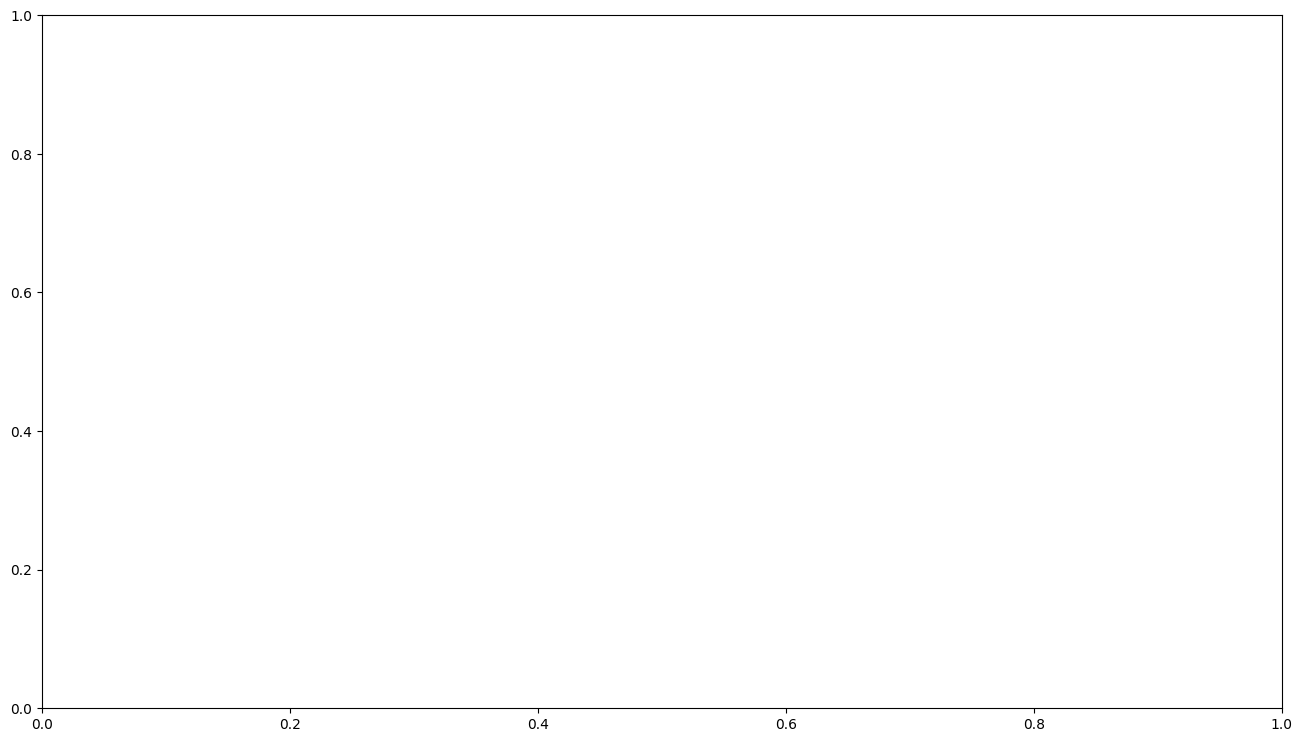

In [119]:
def plot_cm(predicted, actual, model_name):
  fig, ax = plt.subplots(figsize=(16, 9))
  print(sum(actual == 0), sum(predicted == 0), sum(actual == 1), sum(predicted == 1))
  ConfusionMatrixDisplay.from_predictions(actual, predicted, ax=ax, normalize=None, cmap='inferno')
  ax.set_xticklabels(['Predicted 0', 'Predicted 1'])
  ax.set_yticklabels(['Actual 0', 'Actual 1'])
  plt.title(model_name)
  plt.show()
conf_matrix = plot_cm(true_labels, predicted_labels, "GraphSAGE GNN")

In [81]:
precision, recall, fscore, support = precision_recall_fscore_support(true_labels.numpy(), predicted_labels.numpy(), average='macro', zero_division=1)
accuracy = accuracy_score(true_labels.numpy(), predicted_labels.numpy())
print(f"Accuracy: {accuracy*100 :.2f}%\nPrecision: {precision*100 :.2f}%\nRecall: {recall*100 :.2f}%\nfscore: {fscore*100 :.2f}%")

Accuracy: 92.46%
Precision: 92.46%
Recall: 92.46%
fscore: 92.46%


In [123]:
src_nodes = []
dest_nodes = []
true_labels = []
predicted_labels = []

# Define optimizer
optimizer = torch.optim.Adam(itertools.chain(model.parameters(), pred.parameters()), lr=0.01)

# Training loop
for e in range(100):
    # forward
    h = model(train_g, train_g.ndata['features'])
    pos_score = pred(train_pos_g, h)
    neg_score = pred(train_neg_g, h)
    loss = compute_loss(pos_score, neg_score)

    # backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if e % 5 == 0:
        print('In epoch {}, loss: {}'.format(e, loss.item()))

    # Store information for DataFrame
    if e % 10 == 0:
        with torch.no_grad():
            pos_score = pred(test_pos_g, h)
            neg_score = pred(test_neg_g, h)
            # Combine positive and negative scores
            all_scores = torch.cat([pos_score, neg_score]).numpy()
            # True labels (1 for positive, 0 for negative)
            all_labels = torch.cat(
                [torch.ones(pos_score.shape[0]), torch.zeros(neg_score.shape[0])]).numpy()

            # Store information for each edge (up to the minimum length)
            for i in range(min(len(all_scores), len(test_pos_u))):
                src_nodes.append(test_pos_u[i].item())
                dest_nodes.append(test_pos_v[i].item())
                true_labels.append(all_labels[i])
                predicted_labels.append(torch.sigmoid(torch.tensor(all_scores[i])).item())  # Apply sigmoid

# Create DataFrame
df = pd.DataFrame({
    'source_node': src_nodes,
    'destination_node': dest_nodes,
    'true_edge_label': true_labels,
    'predicted_edge_label': predicted_labels
})

# Display the DataFrame
df[(df['true_edge_label'] != 1) & (df['predicted_edge_label'] <= 0.90)]

In epoch 0, loss: 0.16029517352581024
In epoch 5, loss: 0.258234441280365
In epoch 10, loss: 0.29112666845321655
In epoch 15, loss: 0.2523247301578522
In epoch 20, loss: 0.22487209737300873
In epoch 25, loss: 0.20325982570648193
In epoch 30, loss: 0.18614016473293304
In epoch 35, loss: 0.17623986303806305
In epoch 40, loss: 0.17413829267024994
In epoch 45, loss: 0.1699504405260086
In epoch 50, loss: 0.16605859994888306
In epoch 55, loss: 0.16410905122756958
In epoch 60, loss: 0.16218268871307373
In epoch 65, loss: 0.16065086424350739
In epoch 70, loss: 0.15946465730667114
In epoch 75, loss: 0.15853159129619598
In epoch 80, loss: 0.1577068716287613
In epoch 85, loss: 0.15701748430728912
In epoch 90, loss: 0.1563580185174942
In epoch 95, loss: 0.15578709542751312


,source_node,destination_node,true_edge_label,predicted_edge_label


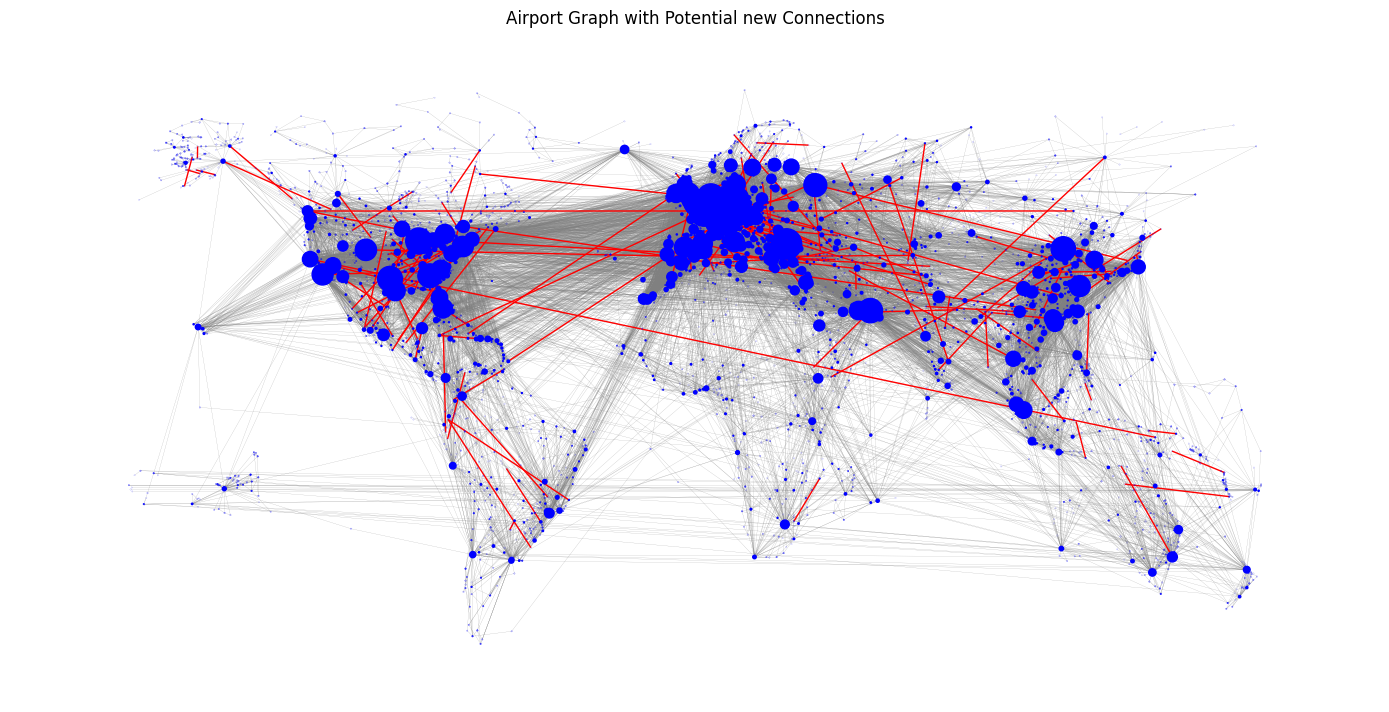

In [ ]:
# Draw the graph
# Draw the graph using custom node positions
plt.figure(figsize=(14,7))

pos = nx.get_node_attributes(G,"location")

#labels = nx.get_node_attributes(G, 'country')
node_size = [0.005*G.degree[v]**2 for v in G]
#node_size=50
alpha = [0.003*G.degree[v] for v in G]
edge_width = [0.0015*G[u][v]['distance'] for u,v in G.edges()]


nx.draw_networkx(G, pos, alpha=1, with_labels=False, edge_color='0.5', node_color='blue', node_size = node_size, width=0.1)
nx.draw_networkx_edges(G, pos, edgelist=new_links, edge_color="red", width=1.0)

plt.axis('off')
plt.tight_layout();
plt.title("Airport Graph with Potential new Connections")
plt.show()